In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib
import os

df = pd.read_csv("../data/model_ready.csv", parse_dates=["service_date"])
df = df.set_index("service_date")

print(df.shape)
print(df.head())

(7609, 14)
             day_type      bus  rail_boardings  total_rides  year  month  \
service_date                                                               
2001-01-31          W   999392          610508      1609900  2001      1   
2001-02-01          W  1054608          615268      1669876  2001      2   
2001-02-02          W   966701          577767      1544468  2001      2   
2001-02-03          A   611703          263612       875315  2001      2   
2001-02-04          U   404212          178398       582610  2001      2   

              day_of_week       period  day_of_year     lag_1     lag_7  \
service_date                                                              
2001-01-31              2  Before 2020           31  607858.0  606835.0   
2001-02-01              3  Before 2020           32  610508.0  609877.0   
2001-02-02              4  Before 2020           33  615268.0  597039.0   
2001-02-03              5  Before 2020           34  577767.0  268078.0   
2001-0

In [2]:
# Cell 2 — Split data into training and testing

target = "rail_boardings"  # Set the value we want to predict

split_index = int(len(df) * 0.8)  # Use 80% for training

train = df.iloc[:split_index].copy()  # Keep earlier data for training
test = df.iloc[split_index:].copy()  # Keep later data for testing

y_train = train[target]  # Training target
y_test = test[target]  # Testing target

print("Training:", train.index.min(), "to", train.index.max())
print("Testing:", test.index.min(), "to", test.index.max())

Training: 2001-01-31 00:00:00 to 2017-09-30 00:00:00
Testing: 2017-10-01 00:00:00 to 2021-11-30 00:00:00


In [3]:
# Cell 3 — Build the ARIMA model

arima_model = ARIMA(
    y_train,
    order=(7, 1, 1)  # ARIMA model settings
)

arima_fit = arima_model.fit()  # Train the model

print(arima_fit.summary())

/Users/ireoluwaonamusi/Desktop/rail-passenger-demand-forecasting/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/ireoluwaonamusi/Desktop/rail-passenger-demand-forecasting/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/ireoluwaonamusi/Desktop/rail-passenger-demand-forecasting/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/ireoluwaonamusi/Desktop/rail-passenger-demand-forecasting/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using

                               SARIMAX Results                                
Dep. Variable:         rail_boardings   No. Observations:                 6087
Model:                 ARIMA(7, 1, 1)   Log Likelihood              -77293.333
Date:                Fri, 07 Aug 2026   AIC                         154604.666
Time:                        19:01:19   BIC                         154665.090
Sample:                    01-31-2001   HQIC                        154625.634
                         - 09-30-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3116      0.049     -6.364      0.000      -0.408      -0.216
ar.L2         -0.4399      0.038    -11.598      0.000      -0.514      -0.366
ar.L3         -0.3708      0.043     -8.593      0.0

In [4]:
# Cell 4 — Generate ARIMA predictions

arima_predictions = arima_fit.forecast(
    steps=len(y_test)  # Predict the entire test period
)

arima_predictions = pd.Series(
    arima_predictions,
    index=y_test.index
)

print(arima_predictions.head())

service_date
2017-10-01    397062.602429
2017-10-02    744315.105292
2017-10-03    798923.914593
2017-10-04    781047.093966
2017-10-05    810413.678438
Name: predicted_mean, dtype: float64


In [5]:
# Cell 5 — Evaluate ARIMA

arima_mae = mean_absolute_error(
    y_test,
    arima_predictions
)  # Calculate average prediction error

arima_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        arima_predictions
    )
)  # Calculate larger errors more heavily

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 294817.58357898914
ARIMA RMSE: 370057.40563397144


In [6]:
# Cell 6 — Select Gradient Boosting features

features = [
    "year",  # Year of the observation
    "month",  # Month of the observation
    "day_of_week",  # Day of the week
    "day_of_year",  # Position in the year
    "lag_1",  # Demand one day ago
    "lag_7",  # Demand seven days ago
    "lag_30",  # Demand thirty days ago
    "rolling_7",  # Average demand over seven days
    "rolling_30"  # Average demand over thirty days
]

X_train = train[features]  # Training features
y_train = train[target]  # Training target

X_test = test[features]  # Testing features
y_test = test[target]  # Testing target

In [7]:
# Cell 7 — Build the Gradient Boosting model

gb_model = GradientBoostingRegressor(
    n_estimators=200,  # Number of boosting stages
    learning_rate=0.05,  # Step size for each stage
    max_depth=3,  # Maximum tree depth
    random_state=42  # Keep results reproducible
)

gb_model.fit(X_train, y_train)  # Train the model

print("Gradient Boosting model trained.")

Gradient Boosting model trained.


In [8]:
# Cell 8 — Generate Gradient Boosting predictions

gb_predictions = gb_model.predict(X_test)  # Predict test demand

gb_predictions = pd.Series(
    gb_predictions,
    index=y_test.index
)

print(gb_predictions.head())

service_date
2017-10-01    378276.896848
2017-10-02    739449.625973
2017-10-03    798127.242711
2017-10-04    810239.085549
2017-10-05    802634.127707
dtype: float64


In [9]:
# Cell 9 — Evaluate Gradient Boosting

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)  # Calculate average prediction error

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)  # Calculate larger errors more heavily

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting MAE: 103704.48198273487
Gradient Boosting RMSE: 156742.19056391963


In [10]:
# Cell 10 — Compare both models

results = pd.DataFrame({
    "Model": ["ARIMA", "Gradient Boosting"],
    "MAE": [arima_mae, gb_mae],
    "RMSE": [arima_rmse, gb_rmse]
})

print(results)

               Model            MAE           RMSE
0              ARIMA  294817.583579  370057.405634
1  Gradient Boosting  103704.481983  156742.190564


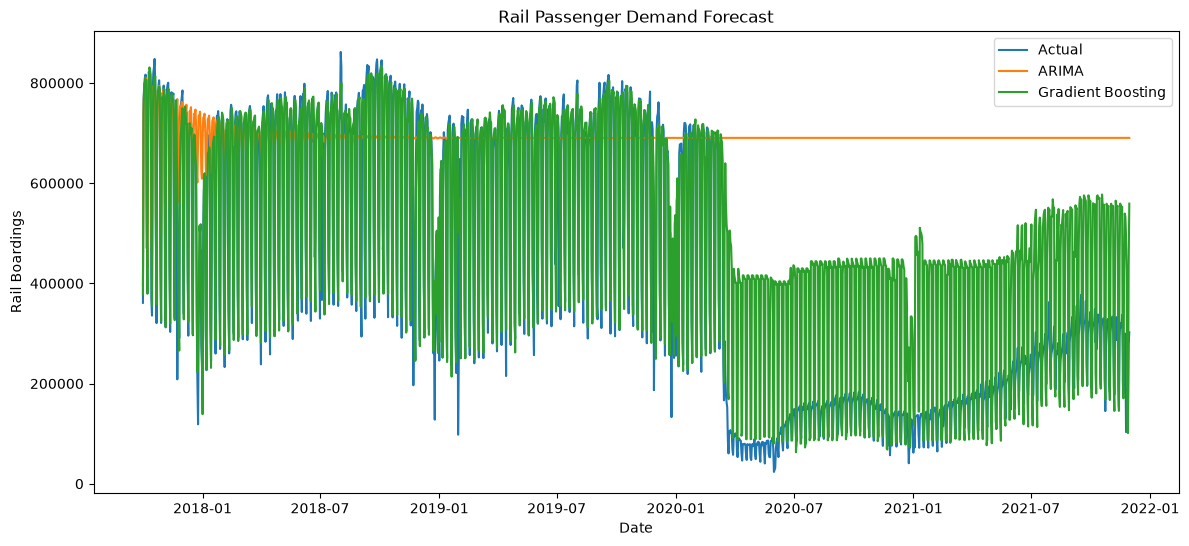

In [11]:
# Cell 11 — Plot actual vs predicted demand

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    arima_predictions.index,
    arima_predictions,
    label="ARIMA"
)

plt.plot(
    gb_predictions.index,
    gb_predictions,
    label="Gradient Boosting"
)

plt.title("Rail Passenger Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Rail Boardings")
plt.legend()
plt.show()

In [12]:
# Cell 12 — Create models folder

os.makedirs("../models", exist_ok=True)  # Create folder if it doesn't exist

In [13]:
# Cell 13 — Save trained models

joblib.dump(
    arima_fit,
    "../models/arima_model.pkl"
)  # Save ARIMA model

joblib.dump(
    gb_model,
    "../models/gradient_boosting_model.pkl"
)  # Save Gradient Boosting model

print("Models saved.")

Models saved.


In [14]:
# Cell 14 — Save model comparison

results.to_csv(
    "../models/model_comparison.csv",
    index=False
)  # Save evaluation results

print("Results saved.")

Results saved.


In [16]:
# Check which features mattered most

importance = pd.Series(
    gb_model.feature_importances_,
    index=features
).sort_values(ascending=False)  # Rank features from most to least important

print(importance)

day_of_week    0.702338
lag_1          0.104149
rolling_7      0.058978
lag_7          0.050771
day_of_year    0.043774
rolling_30     0.028153
year           0.008752
lag_30         0.002722
month          0.000363
dtype: float64


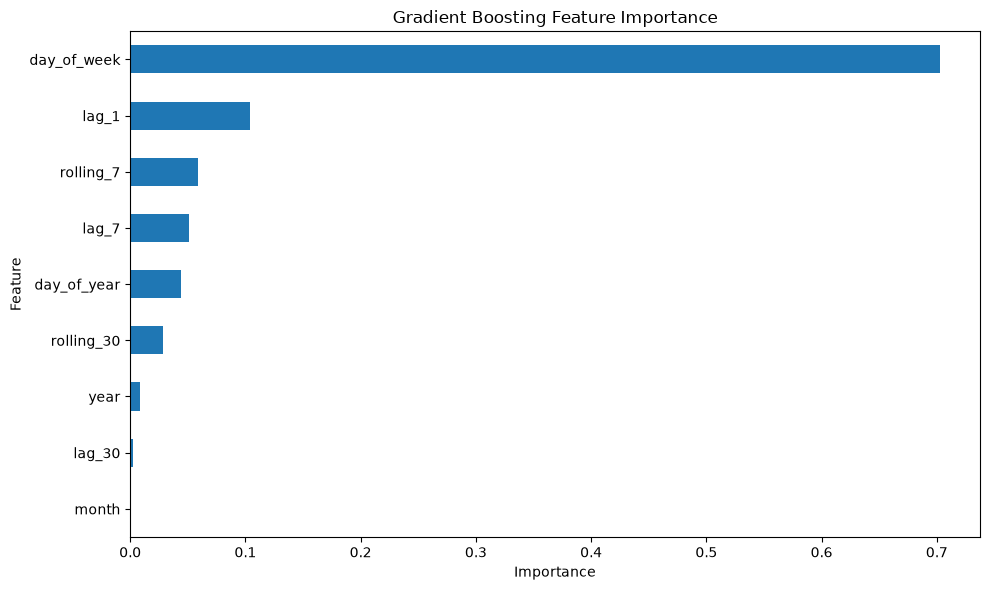

In [17]:
# Plot feature importance

plt.figure(figsize=(10, 6))

importance.sort_values().plot(kind="barh")

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [18]:
# Save feature importance

importance.to_csv(
    "../models/feature_importance.csv"
)

print("Feature importance saved.")

Feature importance saved.


In [19]:
# Save the final model comparison

results.to_csv(
    "../models/model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.
